# 04 — Desafio 1: Previsão de Volume (SARIMAX) | Projeto Chronos — v4 (Bottom-Up)

**O que muda nesta versão, em relação à v3:**

1. **Abordagem Bottom-Up**: P2 (Alta) e P3 (Média) têm comportamento diferente (achado da EDA e confirmado na Parte 0 abaixo) — em vez de modelar a soma direto, treinamos **um modelo para cada prioridade** e somamos as previsões no final. A ideia: cada modelo aprende a curva específica da sua prioridade, em vez de uma curva combinada que borra os dois padrões.
2. **Removida a projeção semanal direta (W+1)** — na v3 essa seção ficou pouco integrada ao resto do notebook; a previsão semanal, quando precisar, é a soma dos 7 dias do modelo de produção (já documentado como a abordagem mais defensável desde a v2).
3. **Novo baseline: CatBoost Regressor**, competindo com o ARIMAX — nota completa na Parte 3 sobre por que CatBoost em vez de LSTM (recomendação do professor de DL).
4. **Nova Parte 0**: antes de qualquer modelo, destrinchamos o que é ruído, sazonalidade e padrão nas séries de P2 e P3, separadamente — com decomposição STL, ACF/PACF e a investigação de saltos anômalos já usada na v3.
5. **Rigor estatístico mantido integralmente**: `d=1` forçado (ADF/KPSS), `max_p=3`/`max_q=3`, seleção por BIC, walk-forward em 3 folds, teste de parcimônia, ensemble testado (não assumido), escala bruta vs. `log1p` com correção de Duan, diagnóstico formal de resíduos (Ljung-Box/Breusch-Pagan/Jarque-Bera), IC por bootstrap dos resíduos.

**Decisão de arquitetura**: as séries diárias de P2 e P3 (elegíveis para KPI) **não vêm de `gold_volume_diario`** — essa tabela só tem a soma de P2+P3, não separadas por prioridade. Em vez de alterar a Gold pela terceira vez, agregamos direto de `gold_chamados_risco` (que já tem `Aberto`, `Prioridade` e `Entrou para KPI?` por chamado) — mantém a Gold genérica, e a decisão de modelar bottom-up fica no notebook que a usa. As exógenas de calendário continuam vindo de `gold_volume_diario` (são as mesmas para P2 e P3, não dependem de prioridade).


In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [3]:
import sys
sys.path.append('/content/drive/MyDrive/cronos_project')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import (
    setup_logging, PROJECT_PATHS, load_parquet_layer, generate_expanding_folds,
    calcular_metricas_serie, compute_all_baselines, baseline_rolling_mean,
    SPECS_SARIMAX_PADRAO, rodar_variante_sarimax, construir_exogenas_futuras,
    monitorar_teto_contratual, detectar_saltos_anomalos, bootstrap_prediction_interval,
    log1p_bias_corrected_forecast, diagnostico_residuos,
    construir_features_tabulares_serie, treinar_catboost_regressor_fold,
    salvar_artefato,
)

logger = setup_logging('sarimax_bottomup')


In [4]:
!pip install pmdarima catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00


In [5]:
import pmdarima as pm
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


---
## PARTE 0 — Entendendo as séries antes de modelar: ruído, sazonalidade e padrão

Antes de ajustar qualquer modelo, vale ser explícito sobre três conceitos que se confundem fácil quando se olha uma série temporal pela primeira vez:

- **Ruído**: variação de curto prazo, sem estrutura previsível — um dia aleatoriamente mais alto ou mais baixo que o esperado, sem repetir num padrão. Os 7 saltos anômalos que já identificamos na v3 (2 deles ligados a incidente em massa) são o exemplo mais claro de ruído nesta série: eventos pontuais que nenhum modelo baseado só no próprio histórico deveria ser cobrado por prever.
- **Sazonalidade**: padrão que se repete em intervalo **fixo e conhecido** — aqui, o candidato natural é o efeito de dia da semana (chamados que abrem menos no fim de semana, por exemplo). É "previsível" porque sabemos de antemão quando ele vai se repetir.
- **Padrão/tendência**: mudança de **nível sustentada** ao longo do tempo — um crescimento ou queda que persiste por várias semanas, não um pico isolado.

A decomposição STL abaixo separa esses três componentes de forma visual e numérica — feita **separadamente para P2 e P3**, porque a hipótese de trabalho (a razão de fazer bottom-up) é que esses componentes têm peso diferente nas duas séries.


### 0.1 Carga das séries P2 e P3 (elegíveis para KPI), separadas por prioridade

2026-08-28 20:29:17 | INFO     | sarimax_bottomup | Lido de /content/drive/MyDrive/cronos_project/data/gold/gold_chamados_risco.parquet: 121811 linhas x 35 colunas (2 colunas de metadado: ['_ingested_at', '_source_layer']).


INFO:sarimax_bottomup:Lido de /content/drive/MyDrive/cronos_project/data/gold/gold_chamados_risco.parquet: 121811 linhas x 35 colunas (2 colunas de metadado: ['_ingested_at', '_source_layer']).


2026-08-28 20:29:18 | INFO     | sarimax_bottomup | Série P2 (elegível): 365 dias, média 14.1/dia, total 5159 no ano.


INFO:sarimax_bottomup:Série P2 (elegível): 365 dias, média 14.1/dia, total 5159 no ano.


2026-08-28 20:29:18 | INFO     | sarimax_bottomup | Série P3 (elegível): 365 dias, média 54.8/dia, total 19997 no ano.


INFO:sarimax_bottomup:Série P3 (elegível): 365 dias, média 54.8/dia, total 19997 no ano.


2026-08-28 20:29:18 | INFO     | sarimax_bottomup | Lido de /content/drive/MyDrive/cronos_project/data/gold/gold_volume_diario.parquet: 365 linhas x 21 colunas (2 colunas de metadado: ['_ingested_at', '_source_layer']).


INFO:sarimax_bottomup:Lido de /content/drive/MyDrive/cronos_project/data/gold/gold_volume_diario.parquet: 365 linhas x 21 colunas (2 colunas de metadado: ['_ingested_at', '_source_layer']).


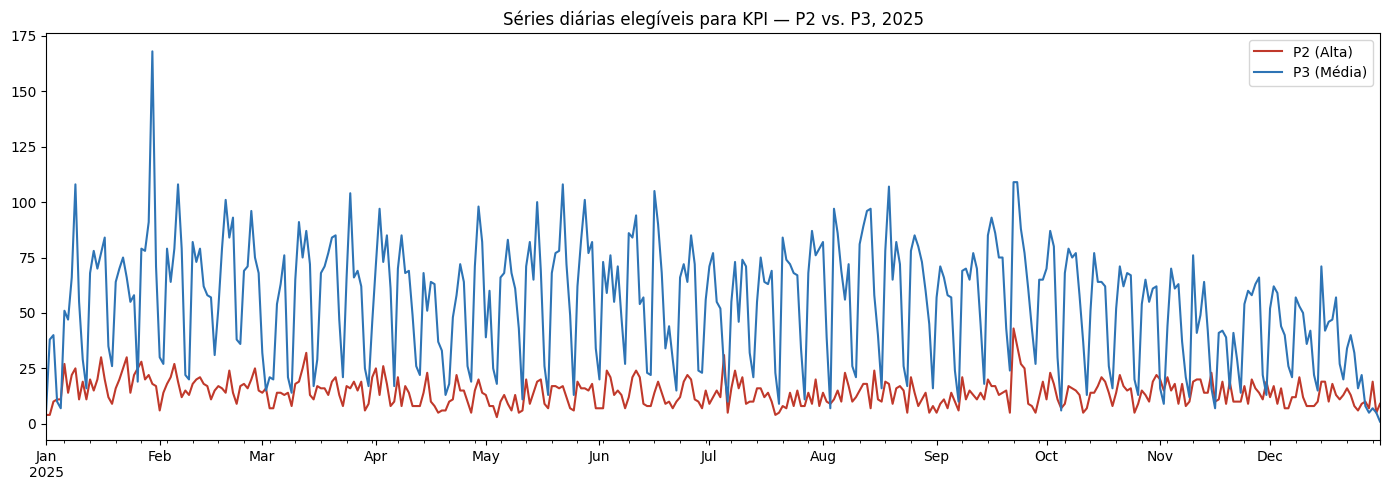

In [6]:
gold_risco_path = PROJECT_PATHS.gold / 'gold_chamados_risco.parquet'
df_risco = load_parquet_layer(gold_risco_path, logger=logger)
df_risco['Aberto'] = pd.to_datetime(df_risco['Aberto'])
df_risco['data'] = df_risco['Aberto'].dt.date

df_elegivel = df_risco[df_risco['Entrou para KPI?'] == 'SIM'].copy()

serie_p2 = df_elegivel[df_elegivel['Prioridade'] == '2 - Alta'].groupby('data').size()
serie_p3 = df_elegivel[df_elegivel['Prioridade'] == '3 - Média'].groupby('data').size()

# Reindexa as duas para o calendário completo de 2025 (365 dias), preenchendo dias sem
# chamado elegível daquela prioridade com 0 — nunca com NaN, que quebraria o Auto-ARIMA.
indice_completo = pd.date_range('2025-01-01', '2025-12-31', freq='D')
serie_p2.index = pd.to_datetime(serie_p2.index)
serie_p3.index = pd.to_datetime(serie_p3.index)
serie_p2 = serie_p2.reindex(indice_completo, fill_value=0)
serie_p3 = serie_p3.reindex(indice_completo, fill_value=0)

logger.info('Série P2 (elegível): %d dias, média %.1f/dia, total %d no ano.', len(serie_p2), serie_p2.mean(), serie_p2.sum())
logger.info('Série P3 (elegível): %d dias, média %.1f/dia, total %d no ano.', len(serie_p3), serie_p3.mean(), serie_p3.sum())

# Exógenas de calendário — as mesmas para P2 e P3 (não dependem de prioridade),
# reaproveitadas de gold_volume_diario.
gold_volume_path = PROJECT_PATHS.gold / 'gold_volume_diario.parquet'
gold_volume_ref = load_parquet_layer(gold_volume_path, logger=logger)
gold_volume_ref['data'] = pd.to_datetime(gold_volume_ref['data'])
exogenas = gold_volume_ref.set_index('data')[['fim_de_semana', 'feriado', 'vespera_feriado', 'dia_seguinte_feriado', 'dow_sin', 'dow_cos']]
exogenas = exogenas.reindex(indice_completo)

fig, ax = plt.subplots(figsize=(14, 5))
serie_p2.plot(ax=ax, label='P2 (Alta)', color='#c0392b')
serie_p3.plot(ax=ax, label='P3 (Média)', color='#2E74B5')
ax.legend()
ax.set_title('Séries diárias elegíveis para KPI — P2 vs. P3, 2025')
plt.tight_layout()
plt.show()


### 0.1.1 Bruta vs. elegível — por que modelamos a elegível, mostrando as duas

**Nota de transparência sobre o enunciado**: o objetivo "Antecipar incidentes" (previsão de volume D+1/D+7) não amarra explicitamente a prioridade obrigatória — essa exigência ("P2 e P3 obrigatórias") aparece formalmente ligada ao objetivo "Identificar tendências". A conexão entre "prever volume" e "usar só o elegível para KPI" é uma inferência forte (a tabela oficial de metas anuais só fecha matematicamente sobre o elegível, e os números reais de 2025 bateram exatamente nas faixas oficiais usando esse recorte — ver validação cruzada no notebook do CatBoost), mas não é uma frase literal do documento do desafio.

Por isso, em vez de decidir silenciosamente por um dos dois recortes, mostramos as duas séries lado a lado abaixo — e documentamos a escolha explicitamente: **modelamos a série elegível como principal**, porque é o único recorte auditável contra o KPI oficial da Locaweb; a série bruta é reportada aqui como contexto operacional, não como concorrente de modelagem (misturar as duas reintroduziria o problema que já corrigimos: perda de sazonalidade por ruído de monitoramento automático).

2026-08-28 20:29:21 | INFO     | sarimax_bottomup | Série P2 (bruta, sem filtro de KPI): média 42.9/dia, total 15645 no ano.


INFO:sarimax_bottomup:Série P2 (bruta, sem filtro de KPI): média 42.9/dia, total 15645 no ano.


2026-08-28 20:29:21 | INFO     | sarimax_bottomup | Série P3 (bruta, sem filtro de KPI): média 113.0/dia, total 41260 no ano.


INFO:sarimax_bottomup:Série P3 (bruta, sem filtro de KPI): média 113.0/dia, total 41260 no ano.


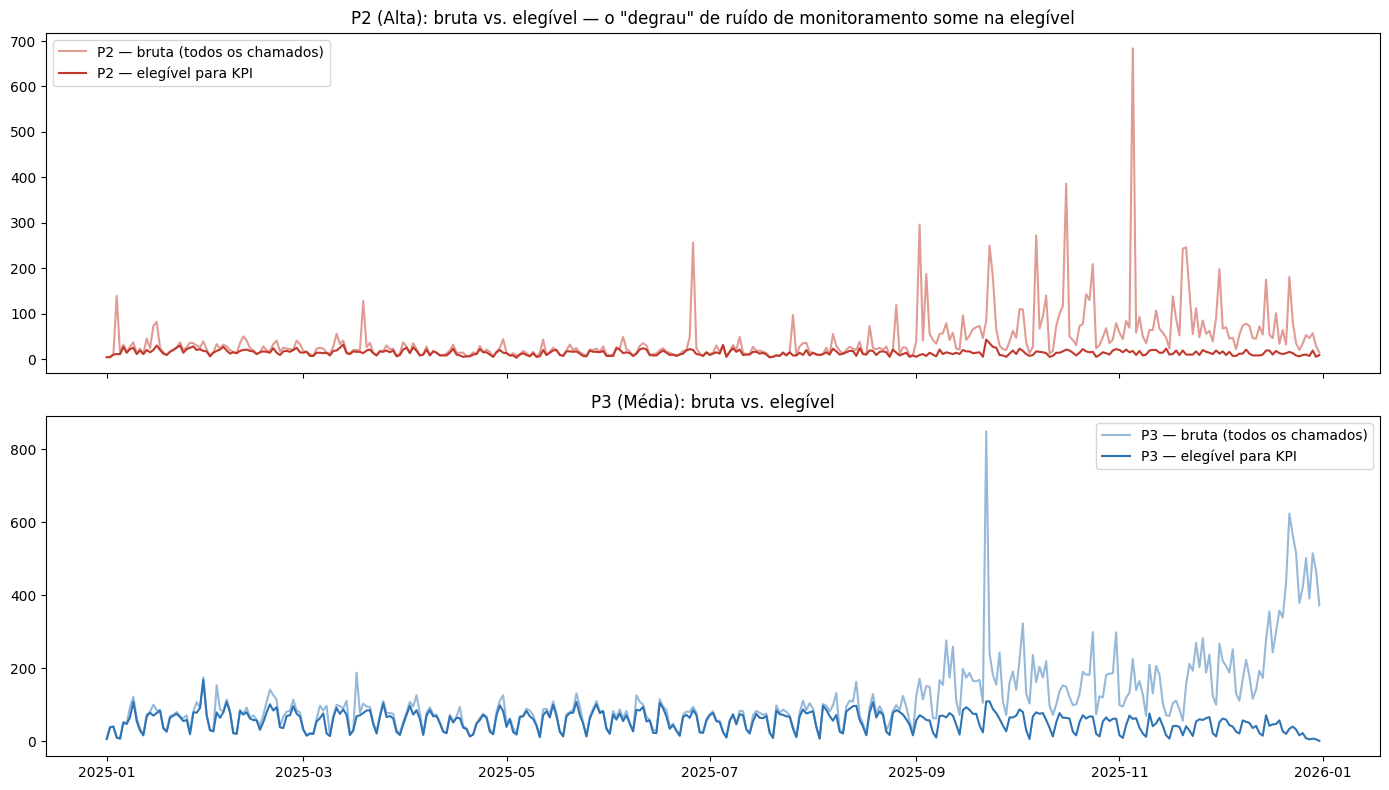

2026-08-28 20:29:22 | INFO     | sarimax_bottomup | P2: a série bruta tem 3.0x mais chamados que a elegível no ano.


INFO:sarimax_bottomup:P2: a série bruta tem 3.0x mais chamados que a elegível no ano.


2026-08-28 20:29:22 | INFO     | sarimax_bottomup | P3: a série bruta tem 2.1x mais chamados que a elegível no ano.


INFO:sarimax_bottomup:P3: a série bruta tem 2.1x mais chamados que a elegível no ano.


In [7]:
# Séries BRUTAS (sem filtro de Entrou para KPI?) — só para contexto visual/textual nesta
# seção. Não alimentam nenhum modelo deste notebook.
serie_p2_bruta = df_risco[df_risco['Prioridade'] == '2 - Alta'].groupby('data').size()
serie_p3_bruta = df_risco[df_risco['Prioridade'] == '3 - Média'].groupby('data').size()
serie_p2_bruta.index = pd.to_datetime(serie_p2_bruta.index)
serie_p3_bruta.index = pd.to_datetime(serie_p3_bruta.index)
serie_p2_bruta = serie_p2_bruta.reindex(indice_completo, fill_value=0)
serie_p3_bruta = serie_p3_bruta.reindex(indice_completo, fill_value=0)

logger.info('Série P2 (bruta, sem filtro de KPI): média %.1f/dia, total %d no ano.', serie_p2_bruta.mean(), serie_p2_bruta.sum())
logger.info('Série P3 (bruta, sem filtro de KPI): média %.1f/dia, total %d no ano.', serie_p3_bruta.mean(), serie_p3_bruta.sum())

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(serie_p2_bruta.index, serie_p2_bruta.values, label='P2 — bruta (todos os chamados)', color='#c0392b', alpha=0.5)
axes[0].plot(serie_p2.index, serie_p2.values, label='P2 — elegível para KPI', color='#c0392b')
axes[0].legend()
axes[0].set_title('P2 (Alta): bruta vs. elegível — o "degrau" de ruído de monitoramento some na elegível')

axes[1].plot(serie_p3_bruta.index, serie_p3_bruta.values, label='P3 — bruta (todos os chamados)', color='#2E74B5', alpha=0.5)
axes[1].plot(serie_p3.index, serie_p3.values, label='P3 — elegível para KPI', color='#2E74B5')
axes[1].legend()
axes[1].set_title('P3 (Média): bruta vs. elegível')

plt.tight_layout()
plt.show()

razao_p2 = serie_p2_bruta.sum() / serie_p2.sum()
razao_p3 = serie_p3_bruta.sum() / serie_p3.sum()
logger.info('P2: a série bruta tem %.1fx mais chamados que a elegível no ano.', razao_p2)
logger.info('P3: a série bruta tem %.1fx mais chamados que a elegível no ano.', razao_p3)


### 0.2 Decomposição STL — separando tendência, sazonalidade e resíduo

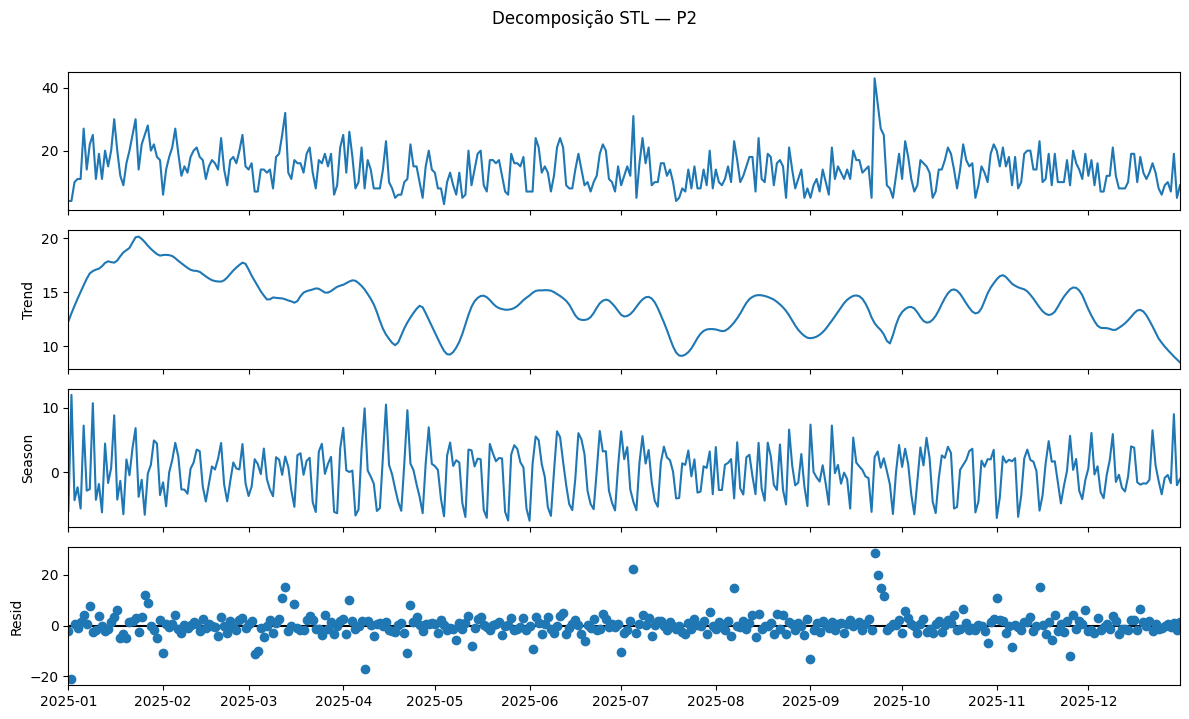

2026-08-28 20:29:25 | INFO     | sarimax_bottomup | P2: força da sazonalidade=0.332 | força da tendência=0.231 (0=ausente, 1=domina)


INFO:sarimax_bottomup:P2: força da sazonalidade=0.332 | força da tendência=0.231 (0=ausente, 1=domina)


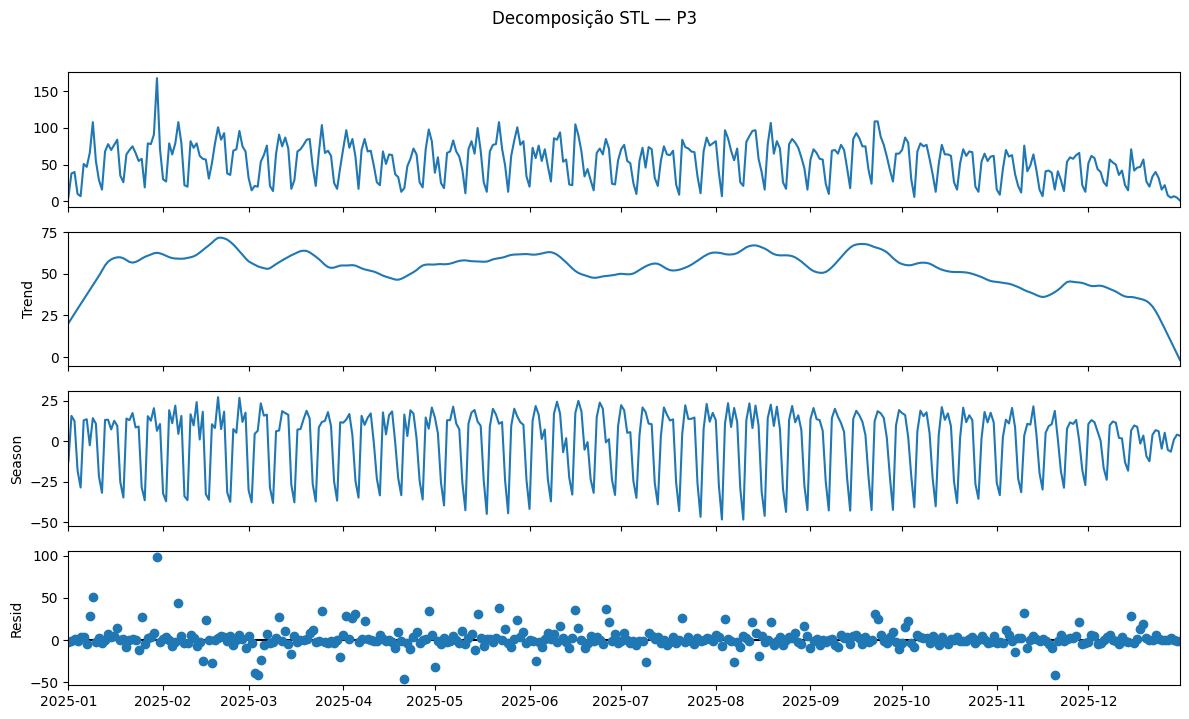

2026-08-28 20:29:30 | INFO     | sarimax_bottomup | P3: força da sazonalidade=0.737 | força da tendência=0.461 (0=ausente, 1=domina)


INFO:sarimax_bottomup:P3: força da sazonalidade=0.737 | força da tendência=0.461 (0=ausente, 1=domina)


In [8]:
SERIES = {'P2': serie_p2, 'P3': serie_p3}
resultados_stl = {}

for nome, serie in SERIES.items():
    stl = STL(serie, period=7, robust=True)
    resultado = stl.fit()
    resultados_stl[nome] = resultado

    fig = resultado.plot()
    fig.set_size_inches(12, 7)
    fig.suptitle(f'Decomposição STL — {nome}', y=1.02)
    plt.tight_layout()
    plt.show()

    forca_sazonalidade = max(0, 1 - resultado.resid.var() / (resultado.seasonal + resultado.resid).var())
    forca_tendencia = max(0, 1 - resultado.resid.var() / (resultado.trend + resultado.resid).var())
    logger.info('%s: força da sazonalidade=%.3f | força da tendência=%.3f (0=ausente, 1=domina)', nome, forca_sazonalidade, forca_tendencia)


**Como ler `força da sazonalidade`/`força da tendência`:** são métricas padrão de decomposição STL (Hyndman) — 0 significa que o componente não explica quase nada da variância da série; perto de 1 significa que ele domina. Se P2 e P3 tiverem forças bem diferentes, é a primeira evidência numérica (não só visual) de que elas merecem modelos separados.

### 0.3 ACF/PACF — o padrão de autocorrelação de cada série

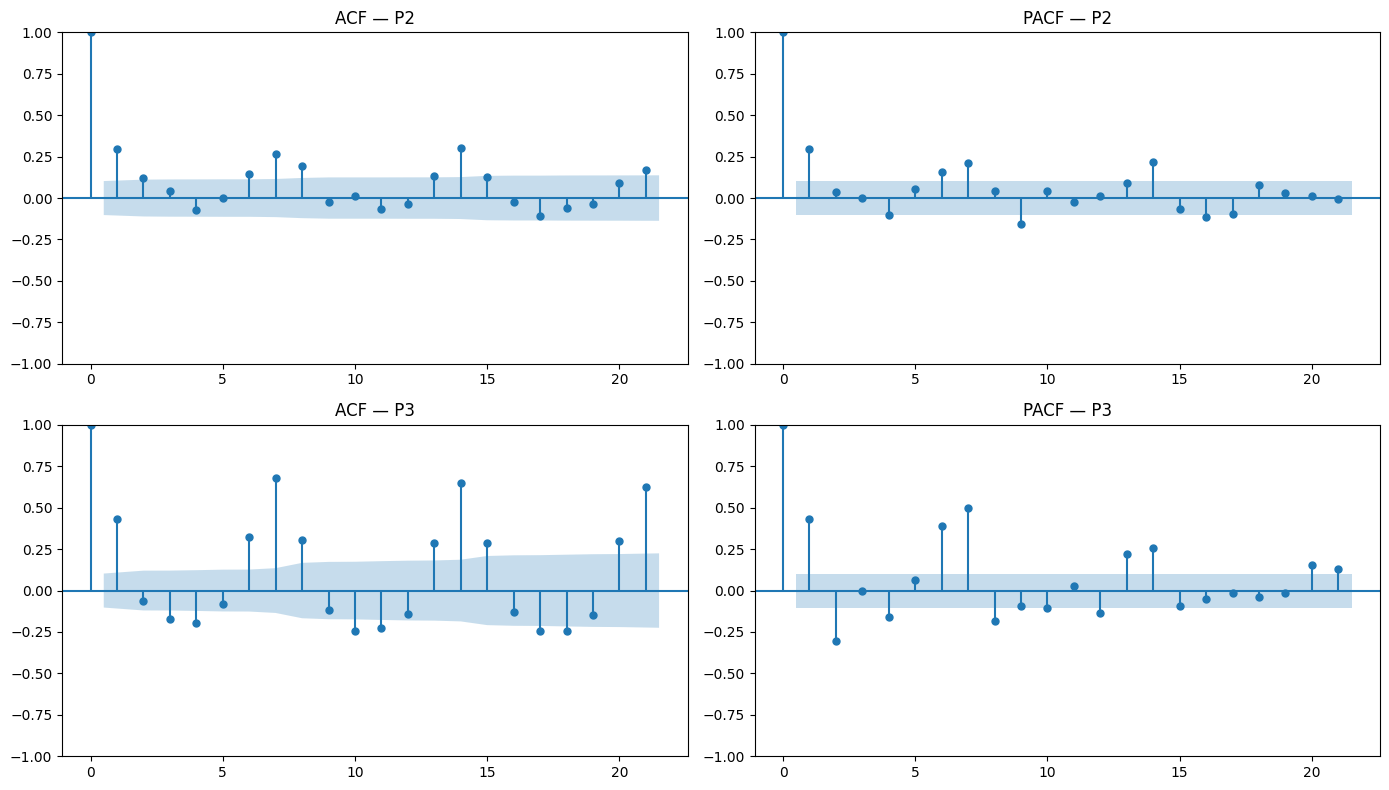

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for i, (nome, serie) in enumerate(SERIES.items()):
    plot_acf(serie, lags=21, ax=axes[i, 0], title=f'ACF — {nome}')
    plot_pacf(serie, lags=21, ax=axes[i, 1], title=f'PACF — {nome}')
plt.tight_layout()
plt.show()


**Como ler:** picos na ACF a cada 7 lags confirmam sazonalidade semanal de forma estatística (não só visual, como na STL). Diferenças na forma da ACF/PACF entre P2 e P3 reforçam (ou não) a decisão de modelar cada uma separadamente — se as duas tiverem exatamente o mesmo formato, o ganho do bottom-up seria menor do que se esperava.

### 0.4 Investigação de saltos anômalos (ruído) — separada por prioridade

Reaproveita `detectar_saltos_anomalos` (já usada na v3 para a série combinada) — agora rodada separadamente, para checar se os mesmos dias aparecem como anômalos nas duas prioridades, ou se é um fenômeno específico de uma delas.

In [10]:
saltos_por_serie = {}
for nome, serie in SERIES.items():
    saltos = detectar_saltos_anomalos(serie, limiar_desvios=3.0)
    saltos_por_serie[nome] = saltos
    logger.info('%s: %d saltos anômalos detectados.', nome, len(saltos))
    if len(saltos):
        display(saltos)


2026-08-28 20:29:30 | INFO     | sarimax_bottomup | P2: 2 saltos anômalos detectados.


INFO:sarimax_bottomup:P2: 2 saltos anômalos detectados.


,data,valor,variacao_dia_anterior,desvios_padrao
0,2025-07-06,5,-26.0,-3.7
1,2025-09-22,43,38.0,5.4


2026-08-28 20:29:31 | INFO     | sarimax_bottomup | P3: 3 saltos anômalos detectados.


INFO:sarimax_bottomup:P3: 3 saltos anômalos detectados.


,data,valor,variacao_dia_anterior,desvios_padrao
0,2025-01-31,71,-97.0,-3.45
1,2025-08-04,97,90.0,3.20
2,2025-09-22,109,85.0,3.02


### 0.5 Síntese — o que é ruído, sazonalidade e padrão em P2 e P3, com número real

Preencher após rodar as células acima: comparar `força da sazonalidade`/`força da tendência` (0.2), o formato da ACF/PACF (0.3), e a lista de saltos anômalos (0.4) entre P2 e P3 — e escrever aqui a conclusão (ex.: "P2 tem sazonalidade semanal mais forte que P3, e os saltos anômalos de incidente em massa afetam P2 desproporcionalmente porque prioridade Alta é mais comum em cascata"). Essa síntese é o argumento de negócio por trás da decisão bottom-up, não só uma decisão técnica.

---
## PARTE 1 — Folds walk-forward

Mesmos 3 folds (mesmos limites de semana) usados no Desafio 3 e nas versões anteriores deste notebook — compartilhados entre P2 e P3, para que as duas modelagens sejam comparáveis e para manter consistência entre desafios.

In [11]:
folds = generate_expanding_folds(start_date='2025-01-01', min_train_weeks=30, test_weeks=7, n_folds=3)
for f in folds:
    logger.info(
        "Fold %d: treino %s a %s (%d dias) | teste %s a %s (%d dias)",
        f['fold'], f['train_start'].date(), f['train_end'].date(),
        (f['train_end'] - f['train_start']).days + 1,
        f['test_start'].date(), f['test_end'].date(),
        (f['test_end'] - f['test_start']).days + 1,
    )


2026-08-28 20:29:31 | INFO     | sarimax_bottomup | Fold 1: treino 2025-01-01 a 2025-07-29 (210 dias) | teste 2025-07-30 a 2025-09-16 (49 dias)


INFO:sarimax_bottomup:Fold 1: treino 2025-01-01 a 2025-07-29 (210 dias) | teste 2025-07-30 a 2025-09-16 (49 dias)


2026-08-28 20:29:31 | INFO     | sarimax_bottomup | Fold 2: treino 2025-01-01 a 2025-09-16 (259 dias) | teste 2025-09-17 a 2025-11-04 (49 dias)


INFO:sarimax_bottomup:Fold 2: treino 2025-01-01 a 2025-09-16 (259 dias) | teste 2025-09-17 a 2025-11-04 (49 dias)


2026-08-28 20:29:31 | INFO     | sarimax_bottomup | Fold 3: treino 2025-01-01 a 2025-11-04 (308 dias) | teste 2025-11-05 a 2025-12-23 (49 dias)


INFO:sarimax_bottomup:Fold 3: treino 2025-01-01 a 2025-11-04 (308 dias) | teste 2025-11-05 a 2025-12-23 (49 dias)


---
## PARTE 2 — Modelagem Bottom-Up: competição de variantes, por prioridade

Em vez de duplicar cada célula para P2 e para P3, o loop abaixo roda a **mesma competição de especificações** (guardrails idênticos aos da v3: `d=1`, `max_p=3`/`max_q=3`, BIC) para cada série, guardando os resultados num dicionário indexado por prioridade — mais fácil de manter e comparar do que duplicar o notebook inteiro.

In [12]:
nomes_variantes = ['sarima_classico', 'arimax_fourier', 'sarimax_hibrido']

resultados_por_serie = {}  # resultados_por_serie['P2'][fold]['arimax_fourier'] = {...}

for nome_serie, serie in SERIES.items():
    logger.info('========== Série %s ==========', nome_serie)
    resultados_fold = []
    modelos_por_fold = {}

    for f in folds:
        treino_mask = (serie.index >= f['train_start']) & (serie.index <= f['train_end'])
        teste_mask = (serie.index >= f['test_start']) & (serie.index <= f['test_end'])
        serie_treino, serie_teste = serie[treino_mask], serie[teste_mask]
        exog_treino, exog_teste = exogenas[treino_mask], exogenas[teste_mask]

        previsoes = compute_all_baselines(serie_treino, len(serie_teste))

        modelos_por_fold[f['fold']] = {}
        for nome_variante in nomes_variantes:
            info = rodar_variante_sarimax(nome_variante, SPECS_SARIMAX_PADRAO[nome_variante], serie_treino, serie_teste, exog_treino, exog_teste)
            previsoes[nome_variante] = info['previsao']
            modelos_por_fold[f['fold']][nome_variante] = info
            assert info['ordem'][1] == 1, f'{nome_serie} fold {f["fold"]} [{nome_variante}]: d deveria ser 1!'

        for nome_modelo, y_previsto in previsoes.items():
            m = calcular_metricas_serie(serie_teste.values, y_previsto)
            resultados_fold.append({'serie': nome_serie, 'fold': f['fold'], 'modelo': nome_modelo, **{f'{k}_horizonte': v for k, v in m.items()}})

    resultados_por_serie[nome_serie] = {'resultados_fold': pd.DataFrame(resultados_fold), 'modelos_por_fold': modelos_por_fold}
    logger.info('%s: competição concluída nos 3 folds.', nome_serie)


2026-08-28 20:29:31 | INFO     | sarimax_bottomup | ========== Série P2 ==========


INFO:sarimax_bottomup:========== Série P2 ==========


2026-08-28 20:37:12 | INFO     | sarimax_bottomup | P2: competição concluída nos 3 folds.


INFO:sarimax_bottomup:P2: competição concluída nos 3 folds.


2026-08-28 20:37:12 | INFO     | sarimax_bottomup | ========== Série P3 ==========


INFO:sarimax_bottomup:========== Série P3 ==========


2026-08-28 20:47:10 | INFO     | sarimax_bottomup | P3: competição concluída nos 3 folds.


INFO:sarimax_bottomup:P3: competição concluída nos 3 folds.


---
## PARTE 3 — Comparação consolidada, por prioridade

In [13]:
melhor_variante_por_serie = {}

for nome_serie in SERIES:
    df_resultados = resultados_por_serie[nome_serie]['resultados_fold']
    resumo = df_resultados.groupby('modelo')[['MAE_horizonte', 'MedAE_horizonte', 'RMSE_horizonte']].mean().round(2).sort_values('MAE_horizonte')
    melhor = resumo.loc[resumo.index.isin(nomes_variantes), 'MAE_horizonte'].idxmin()
    melhor_variante_por_serie[nome_serie] = melhor
    logger.info('%s: melhor variante = %s', nome_serie, melhor)
    print(f'--- {nome_serie} ---')
    display(resumo)


2026-08-28 20:47:10 | INFO     | sarimax_bottomup | P2: melhor variante = arimax_fourier


INFO:sarimax_bottomup:P2: melhor variante = arimax_fourier


--- P2 ---


,MAE_horizonte,MedAE_horizonte,RMSE_horizonte
modelo,,,
arimax_fourier,4.33,3.24,5.85
sarima_classico,4.34,3.71,5.61
sarimax_hibrido,4.48,3.43,5.91
arima_puro,4.56,3.89,5.74
rolling_mean_7d,4.73,4.33,6.14
naive,4.87,4.00,6.11
seasonal_naive,5.20,4.00,6.47


2026-08-28 20:47:10 | INFO     | sarimax_bottomup | P3: melhor variante = sarima_classico


INFO:sarimax_bottomup:P3: melhor variante = sarima_classico


--- P3 ---


,MAE_horizonte,MedAE_horizonte,RMSE_horizonte
modelo,,,
sarima_classico,11.87,9.71,14.69
seasonal_naive,11.90,9.33,14.83
arimax_fourier,12.32,11.29,15.04
sarimax_hibrido,13.17,12.71,15.97
rolling_mean_7d,18.92,15.29,23.63
arima_puro,31.63,25.67,38.25
naive,31.63,25.67,38.25


**Como ler:** se `melhor_variante_por_serie['P2']` e `['P3']` forem diferentes, é mais uma evidência (além da STL/ACF da Parte 0) de que as duas séries têm dinâmicas distintas — reforça a decisão de bottom-up em vez de forçar a mesma especificação nas duas.

---
## PARTE 4 — Teste de parcimônia, por prioridade

Mesmo teste da v3: comparar a especificação vencedora completa contra a versão sem os termos de Fourier (`dow_sin`/`dow_cos`), que já eram estatisticamente irrelevantes no modelo combinado da v3.

In [14]:
especificacao_final_por_serie = {}

for nome_serie, serie in SERIES.items():
    melhor = melhor_variante_por_serie[nome_serie]
    if melhor != 'arimax_fourier':
        # o teste de parcimônia (remover Fourier) só se aplica quando a variante vencedora usa Fourier
        especificacao_final_por_serie[nome_serie] = melhor
        logger.info('%s: melhor variante (%s) não usa Fourier — parcimônia não se aplica, mantendo como está.', nome_serie, melhor)
        continue

    resultados_parcimonia = []
    for f in folds:
        treino_mask = (serie.index >= f['train_start']) & (serie.index <= f['train_end'])
        teste_mask = (serie.index >= f['test_start']) & (serie.index <= f['test_end'])
        serie_treino, serie_teste = serie[treino_mask], serie[teste_mask]
        exog_treino, exog_teste = exogenas[treino_mask], exogenas[teste_mask]

        info_completo = resultados_por_serie[nome_serie]['modelos_por_fold'][f['fold']]['arimax_fourier']
        info_parcimonioso = rodar_variante_sarimax('arimax_fourier_parcimonioso', SPECS_SARIMAX_PADRAO['arimax_fourier_parcimonioso'], serie_treino, serie_teste, exog_treino, exog_teste)

        resultados_parcimonia.append({
            'fold': f['fold'],
            'BIC_completo': info_completo['bic'], 'BIC_parcimonioso': info_parcimonioso['bic'],
            'MAE_completo': calcular_metricas_serie(serie_teste.values, info_completo['previsao'])['MAE'],
            'MAE_parcimonioso': calcular_metricas_serie(serie_teste.values, info_parcimonioso['previsao'])['MAE'],
        })

    df_parcimonia = pd.DataFrame(resultados_parcimonia)
    df_parcimonia['BIC_favorece_parcimonioso'] = df_parcimonia['BIC_parcimonioso'] < df_parcimonia['BIC_completo']
    especificacao_final_por_serie[nome_serie] = 'arimax_fourier_parcimonioso' if df_parcimonia['BIC_favorece_parcimonioso'].mean() > 0.5 else 'arimax_fourier'
    logger.info('%s: especificação final = %s', nome_serie, especificacao_final_por_serie[nome_serie])
    print(f'--- {nome_serie} ---')
    display(df_parcimonia)


2026-08-28 20:47:53 | INFO     | sarimax_bottomup | P2: especificação final = arimax_fourier_parcimonioso


INFO:sarimax_bottomup:P2: especificação final = arimax_fourier_parcimonioso


--- P2 ---


,fold,BIC_completo,BIC_parcimonioso,MAE_completo,MAE_parcimonioso,BIC_favorece_parcimonioso
0,1,1294.8,1292.1,4.64,4.37,True
1,2,1595.3,1587.6,4.66,4.71,True
2,3,1928.4,1920.0,3.69,3.82,True


2026-08-28 20:47:53 | INFO     | sarimax_bottomup | P3: melhor variante (sarima_classico) não usa Fourier — parcimônia não se aplica, mantendo como está.


INFO:sarimax_bottomup:P3: melhor variante (sarima_classico) não usa Fourier — parcimônia não se aplica, mantendo como está.


---
## PARTE 5 — Ensemble e escala, por prioridade

Mesmos dois testes da v3 (ensemble com média móvel; escala bruta vs. `log1p` com correção de Duan) — reaplicados a cada série, porque a conclusão de uma prioridade não pode ser assumida como válida pra outra sem testar.

In [15]:
usar_log_por_serie = {}

for nome_serie, serie in SERIES.items():
    spec_final = SPECS_SARIMAX_PADRAO[especificacao_final_por_serie[nome_serie]]
    f3 = folds[-1]
    treino_mask_f3 = (serie.index >= f3['train_start']) & (serie.index <= f3['train_end'])
    teste_mask_f3 = (serie.index >= f3['test_start']) & (serie.index <= f3['test_end'])
    serie_treino_f3, serie_teste_f3 = serie[treino_mask_f3], serie[teste_mask_f3]
    exog_treino_f3, exog_teste_f3 = exogenas[treino_mask_f3], exogenas[teste_mask_f3]

    # --- Ensemble (todos os 3 folds) ---
    resultados_ensemble = []
    for f in folds:
        treino_mask = (serie.index >= f['train_start']) & (serie.index <= f['train_end'])
        teste_mask = (serie.index >= f['test_start']) & (serie.index <= f['test_end'])
        serie_treino, serie_teste = serie[treino_mask], serie[teste_mask]

        if especificacao_final_por_serie[nome_serie] == melhor_variante_por_serie[nome_serie]:
            previsao_final = resultados_por_serie[nome_serie]['modelos_por_fold'][f['fold']][melhor_variante_por_serie[nome_serie]]['previsao']
        else:
            info = rodar_variante_sarimax(especificacao_final_por_serie[nome_serie], spec_final, serie_treino, serie_teste, exogenas[treino_mask], exogenas[teste_mask])
            previsao_final = info['previsao']

        previsao_rolling = baseline_rolling_mean(serie_treino, len(serie_teste))
        for peso in [1.0, 0.7, 0.5, 0.3, 0.0]:
            combinada = peso * previsao_final + (1 - peso) * previsao_rolling
            resultados_ensemble.append({'fold': f['fold'], 'peso_sarimax': peso, 'MAE': calcular_metricas_serie(serie_teste.values, combinada)['MAE']})

    df_ensemble = pd.DataFrame(resultados_ensemble)
    resumo_ensemble = df_ensemble.groupby('peso_sarimax')['MAE'].mean().round(2).sort_values()
    logger.info('%s: melhor peso do ensemble = %.1f (MAE %.2f)', nome_serie, resumo_ensemble.index[0], resumo_ensemble.iloc[0])

    # --- Escala bruta vs. log1p (todos os 3 folds, com correção de Duan) ---
    resultados_escala = []
    for f in folds:
        treino_mask = (serie.index >= f['train_start']) & (serie.index <= f['train_end'])
        teste_mask = (serie.index >= f['test_start']) & (serie.index <= f['test_end'])
        serie_treino, serie_teste = serie[treino_mask], serie[teste_mask]
        exog_treino, exog_teste = exogenas[treino_mask], exogenas[teste_mask]

        if especificacao_final_por_serie[nome_serie] in resultados_por_serie[nome_serie]['modelos_por_fold'][f['fold']]:
            mae_bruta = calcular_metricas_serie(serie_teste.values, resultados_por_serie[nome_serie]['modelos_por_fold'][f['fold']][especificacao_final_por_serie[nome_serie]]['previsao'])['MAE']
        else:
            info_bruta = rodar_variante_sarimax(especificacao_final_por_serie[nome_serie], spec_final, serie_treino, serie_teste, exog_treino, exog_teste)
            mae_bruta = calcular_metricas_serie(serie_teste.values, info_bruta['previsao'])['MAE']

        X_treino_log = exog_treino[spec_final['X_cols']] if spec_final['X_cols'] else None
        X_teste_log = exog_teste[spec_final['X_cols']] if spec_final['X_cols'] else None
        serie_log_treino = np.log1p(serie_treino)
        modelo_log = pm.auto_arima(
            serie_log_treino, X=X_treino_log, d=1, seasonal=spec_final['seasonal'], m=7 if spec_final['seasonal'] else 1,
            max_p=3, max_q=3, information_criterion='bic', stepwise=True, suppress_warnings=True, error_action='ignore',
        )
        prev_log, _ = modelo_log.predict(n_periods=len(serie_teste), X=X_teste_log, return_conf_int=True)
        residuos_log_treino = serie_log_treino.values - modelo_log.predict_in_sample(X=X_treino_log)
        prev_log_corrigida = log1p_bias_corrected_forecast(np.asarray(prev_log), residuos_log_treino)
        mae_log = calcular_metricas_serie(serie_teste.values, prev_log_corrigida)['MAE']

        resultados_escala.append({'fold': f['fold'], 'MAE_bruta': mae_bruta, 'MAE_log1p_corrigido': mae_log})

    df_escala = pd.DataFrame(resultados_escala)
    media_bruta, media_log = df_escala['MAE_bruta'].mean(), df_escala['MAE_log1p_corrigido'].mean()
    usar_log_por_serie[nome_serie] = media_log < media_bruta
    logger.info('%s: escala escolhida = %s (bruta=%.2f, log1p=%.2f)', nome_serie, 'log1p' if usar_log_por_serie[nome_serie] else 'bruta', media_bruta, media_log)


2026-08-28 20:48:32 | INFO     | sarimax_bottomup | P2: melhor peso do ensemble = 0.7 (MAE 4.28)


INFO:sarimax_bottomup:P2: melhor peso do ensemble = 0.7 (MAE 4.28)


2026-08-28 20:49:45 | INFO     | sarimax_bottomup | P2: escala escolhida = bruta (bruta=4.30, log1p=4.94)


INFO:sarimax_bottomup:P2: escala escolhida = bruta (bruta=4.30, log1p=4.94)


2026-08-28 20:49:45 | INFO     | sarimax_bottomup | P3: melhor peso do ensemble = 1.0 (MAE 11.87)


INFO:sarimax_bottomup:P3: melhor peso do ensemble = 1.0 (MAE 11.87)


2026-08-28 20:54:24 | INFO     | sarimax_bottomup | P3: escala escolhida = bruta (bruta=11.87, log1p=13.38)


INFO:sarimax_bottomup:P3: escala escolhida = bruta (bruta=11.87, log1p=13.38)


---
## PARTE 6 — Baseline adicional: CatBoost Regressor

### 6.1 Nota sobre a escolha de CatBoost em vez de LSTM

O professor de Deep Learning recomendou LSTM como comparativo. A decisão do grupo foi usar **CatBoost Regressor** em vez disso, por três motivos concretos, não por preferência:

1. **Volume de dados**: `gold_volume_diario`/as séries P2 e P3 têm só 365 pontos diários (52 semanas) — uma LSTM tipicamente precisa de bem mais histórico para aprender dependência temporal de forma confiável sem overfitar. Já vimos esse problema de perto: o modelo semanal direto (só 52 pontos) chegou a produzir uma previsão negativa nos testes da v2/v3 deste mesmo notebook.
2. **Reaproveitamento de infraestrutura já validada**: o projeto já tem uma infraestrutura de CatBoost completa, testada e em produção (Desafio 3) — Optuna, avaliação, persistência. Adaptar isso para regressão é rápido e testado; montar e validar uma arquitetura de LSTM do zero, para um ganho que o volume de dados provavelmente não sustenta, tem um custo alto para um baseline comparativo (não é o modelo principal do desafio).
3. **Papel no notebook**: esta seção não decide qual é o "modelo final" do Desafio 1 — é uma segunda forma de validar se o ARIMAX está de fato capturando o sinal disponível. Um regressor de árvore, com os mesmos lags e calendário como features, é uma régua diferente e complementar ao SARIMAX (não-linear, sem suposição de estrutura ARIMA) — LSTM não traria uma régua qualitativamente diferente disso para este volume de dado, e viria com bem mais risco de instabilidade.

Uma LSTM real pode ser construída depois, como uma comparação adicional, se o tempo do grupo permitir — mas não é a escolha para esta entrega.

### 6.2 Preparo das features tabulares e treino, por prioridade

In [16]:
resultados_catboost_por_serie = {}

for nome_serie, serie in SERIES.items():
    tabela = construir_features_tabulares_serie(serie, exogenas, n_lags=7)

    resultados_fold_cb = []
    for f in folds:
        treino_mask = (tabela.index >= f['train_start']) & (tabela.index <= f['train_end'])
        teste_mask = (tabela.index >= f['test_start']) & (tabela.index <= f['test_end'])
        tabela_treino, tabela_teste = tabela[treino_mask], tabela[teste_mask]

        if len(tabela_teste) == 0 or len(tabela_treino) == 0:
            continue

        resultado_cb = treinar_catboost_regressor_fold(tabela_treino, tabela_teste, target_col='y', params={'iterations': 200})
        mae_cb = calcular_metricas_serie(resultado_cb['y_true'], resultado_cb['y_previsto'])['MAE']

        # comparação direta: MAE do ARIMAX vencedor no MESMO fold e MESMO horizonte
        spec_arimax = especificacao_final_por_serie[nome_serie]
        info_arimax = resultados_por_serie[nome_serie]['modelos_por_fold'][f['fold']].get(spec_arimax)
        if info_arimax is not None:
            serie_teste_original = serie[(serie.index >= f['test_start']) & (serie.index <= f['test_end'])]
            mae_arimax_mesmo_horizonte = calcular_metricas_serie(serie_teste_original.values[-len(tabela_teste):], info_arimax['previsao'][-len(tabela_teste):])['MAE']
        else:
            mae_arimax_mesmo_horizonte = np.nan

        resultados_fold_cb.append({'fold': f['fold'], 'MAE_catboost': mae_cb, 'MAE_arimax': mae_arimax_mesmo_horizonte})

    df_cb = pd.DataFrame(resultados_fold_cb)
    resultados_catboost_por_serie[nome_serie] = df_cb
    logger.info('%s: MAE médio CatBoost=%.2f | MAE médio ARIMAX (%s)=%.2f', nome_serie, df_cb['MAE_catboost'].mean(), especificacao_final_por_serie[nome_serie], df_cb['MAE_arimax'].mean())
    print(f'--- {nome_serie}: CatBoost vs. ARIMAX ---')
    display(df_cb)


2026-08-28 20:54:26 | INFO     | sarimax_bottomup | P2: MAE médio CatBoost=4.02 | MAE médio ARIMAX (arimax_fourier_parcimonioso)=nan


INFO:sarimax_bottomup:P2: MAE médio CatBoost=4.02 | MAE médio ARIMAX (arimax_fourier_parcimonioso)=nan


--- P2: CatBoost vs. ARIMAX ---


,fold,MAE_catboost,MAE_arimax
0,1,3.88,NaN
1,2,4.62,NaN
2,3,3.56,NaN


2026-08-28 20:54:27 | INFO     | sarimax_bottomup | P3: MAE médio CatBoost=10.82 | MAE médio ARIMAX (sarima_classico)=11.87


INFO:sarimax_bottomup:P3: MAE médio CatBoost=10.82 | MAE médio ARIMAX (sarima_classico)=11.87


--- P3: CatBoost vs. ARIMAX ---


,fold,MAE_catboost,MAE_arimax
0,1,10.01,9.77
1,2,9.39,11.01
2,3,13.05,14.83


**Como ler:** se o CatBoost vencer o ARIMAX de forma consistente nos 3 folds, isso é um resultado real a reportar (inclusive pode virar o modelo de produção, se a diferença for grande e estável) — não estamos comparando pra confirmar uma escolha já feita, estamos testando de verdade.

---
## PARTE 7 — Visualização — fold 3, especificação final, por prioridade

/tmp/ipykernel_5944/760939860.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(serie_teste_f3.index, info_f3['previsao'], label=f'Previsto ({spec_final})', color='#c0392b', marker='x')
/tmp/ipykernel_5944/760939860.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(serie_teste_f3.index, info_f3['previsao'], label=f'Previsto ({spec_final})', color='#c0392b', marker='x')


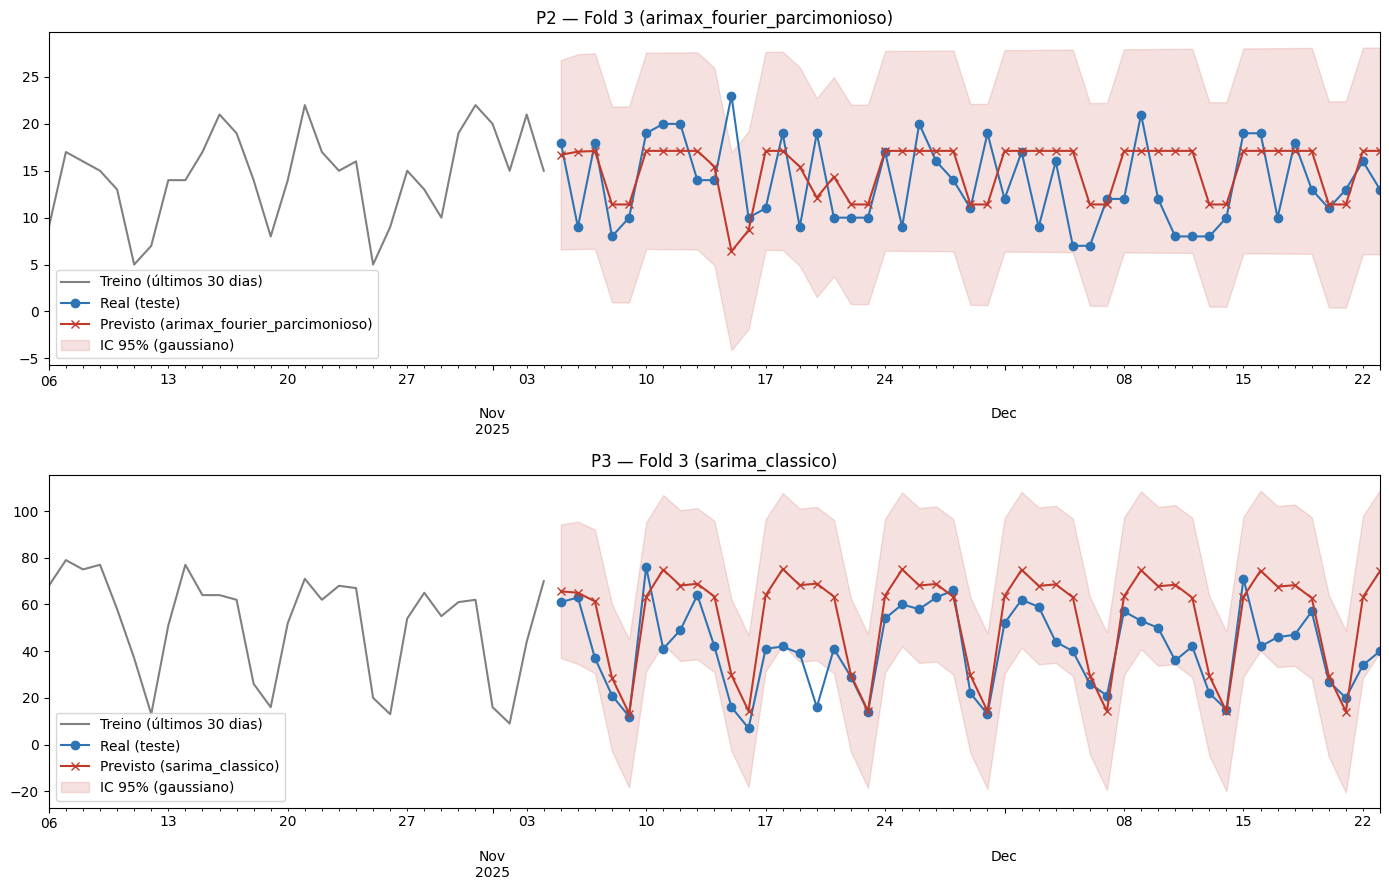

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

for ax, nome_serie in zip(axes, SERIES):
    serie = SERIES[nome_serie]
    f3 = folds[-1]
    treino_mask_f3 = (serie.index >= f3['train_start']) & (serie.index <= f3['train_end'])
    teste_mask_f3 = (serie.index >= f3['test_start']) & (serie.index <= f3['test_end'])
    serie_treino_f3, serie_teste_f3 = serie[treino_mask_f3], serie[teste_mask_f3]

    spec_final = especificacao_final_por_serie[nome_serie]
    info_f3 = resultados_por_serie[nome_serie]['modelos_por_fold'][3].get(spec_final)
    if info_f3 is None:
        info_f3 = rodar_variante_sarimax(spec_final, SPECS_SARIMAX_PADRAO[spec_final], serie_treino_f3, serie_teste_f3, exogenas[treino_mask_f3], exogenas[teste_mask_f3])

    serie_treino_f3.iloc[-30:].plot(ax=ax, label='Treino (últimos 30 dias)', color='grey')
    serie_teste_f3.plot(ax=ax, label='Real (teste)', color='#2E74B5', marker='o')
    ax.plot(serie_teste_f3.index, info_f3['previsao'], label=f'Previsto ({spec_final})', color='#c0392b', marker='x')
    ax.fill_between(serie_teste_f3.index, info_f3['ic'][:, 0], info_f3['ic'][:, 1], color='#c0392b', alpha=0.15, label='IC 95% (gaussiano)')
    ax.legend()
    ax.set_title(f'{nome_serie} — Fold 3 ({spec_final})')

plt.tight_layout()
plt.show()


---
## PARTE 8 — Modelo de produção — P2, P3, e a soma Bottom-Up

In [18]:
modelos_producao = {}
previsoes_producao = {}

for nome_serie, serie in SERIES.items():
    spec_final = SPECS_SARIMAX_PADRAO[especificacao_final_por_serie[nome_serie]]
    X_producao = exogenas[spec_final['X_cols']] if spec_final['X_cols'] else None
    usar_log = usar_log_por_serie[nome_serie]
    serie_para_treino = np.log1p(serie) if usar_log else serie

    modelo_producao = pm.auto_arima(
        serie_para_treino, X=X_producao, d=1, seasonal=spec_final['seasonal'], m=7 if spec_final['seasonal'] else 1,
        max_p=3, max_q=3, information_criterion='bic', stepwise=True, suppress_warnings=True, error_action='ignore',
    )
    assert modelo_producao.order[1] == 1
    modelos_producao[nome_serie] = {'modelo': modelo_producao, 'usar_log': usar_log, 'spec': spec_final}
    logger.info('%s: modelo de produção = %s%sx%s | escala=%s', nome_serie, especificacao_final_por_serie[nome_serie], modelo_producao.order, modelo_producao.seasonal_order, 'log1p' if usar_log else 'bruta')


2026-08-28 20:55:04 | INFO     | sarimax_bottomup | P2: modelo de produção = arimax_fourier_parcimonioso(1, 1, 1)x(0, 0, 0, 0) | escala=bruta


INFO:sarimax_bottomup:P2: modelo de produção = arimax_fourier_parcimonioso(1, 1, 1)x(0, 0, 0, 0) | escala=bruta


2026-08-28 20:57:33 | INFO     | sarimax_bottomup | P3: modelo de produção = sarima_classico(0, 1, 2)x(1, 0, 1, 7) | escala=bruta


INFO:sarimax_bottomup:P3: modelo de produção = sarima_classico(0, 1, 2)x(1, 0, 1, 7) | escala=bruta


In [19]:
datas_futuras = pd.date_range(serie_p2.index.max() + pd.Timedelta(days=1), periods=7, freq='D')

for nome_serie in SERIES:
    info = modelos_producao[nome_serie]
    exog_futuro = construir_exogenas_futuras(datas_futuras[0].strftime('%Y-%m-%d'), 7, colunas=info['spec']['X_cols'])
    previsao, ic = info['modelo'].predict(n_periods=7, X=exog_futuro, return_conf_int=True)
    previsao = np.asarray(previsao)

    if info['usar_log']:
        residuos_treino = np.asarray(info['modelo'].arima_res_.resid)
        previsao_final = log1p_bias_corrected_forecast(previsao, residuos_treino)
        ic_final = np.expm1(ic)
    else:
        previsao_final = previsao
        ic_final = ic

    previsoes_producao[nome_serie] = pd.DataFrame({
        'data': datas_futuras,
        f'previsao_{nome_serie.lower()}': np.round(previsao_final).astype(int),
        f'ic_inferior_{nome_serie.lower()}': np.round(ic_final[:, 0]).astype(int),
        f'ic_superior_{nome_serie.lower()}': np.round(ic_final[:, 1]).astype(int),
    })

# Bottom-Up: soma as previsões de P2 e P3 para obter o total previsto
df_previsao_total = previsoes_producao['P2'].merge(previsoes_producao['P3'], on='data')
df_previsao_total['previsao_total_p2_p3'] = df_previsao_total['previsao_p2'] + df_previsao_total['previsao_p3']
df_previsao_total['ic_inferior_total'] = df_previsao_total['ic_inferior_p2'] + df_previsao_total['ic_inferior_p3']
df_previsao_total['ic_superior_total'] = df_previsao_total['ic_superior_p2'] + df_previsao_total['ic_superior_p3']

df_previsao_total


,data,previsao_p2,ic_inferior_p2,ic_superior_p2,previsao_p3,ic_inferior_p3,ic_superior_p3,previsao_total_p2_p3,ic_inferior_total,ic_superior_total
0,2026-01-01,10,0,20,14,-15,43,24,-15,63
1,2026-01-02,11,1,21,18,-13,49,29,-12,70
2,2026-01-03,9,-2,19,-7,-38,24,2,-40,43
3,2026-01-04,9,-2,19,-17,-49,15,-8,-51,34
4,2026-01-05,14,4,24,19,-13,52,33,-9,76
5,2026-01-06,14,4,24,20,-13,53,34,-9,77
6,2026-01-07,14,4,24,16,-17,49,30,-13,73


**Nota sobre o intervalo de confiança da soma:** somar os limites inferior/superior dos dois ICs (em vez de recalcular a incerteza combinada) é uma aproximação conservadora — assume que os erros de P2 e P3 são perfeitamente correlacionados positivamente, o que tende a produzir um intervalo mais largo do que a incerteza real combinada (se os erros forem parcialmente independentes, o intervalo verdadeiro seria mais estreito). Preferimos errar para um IC mais largo do que subestimar a incerteza da soma.

### 8.1 Coeficientes e diagnóstico formal de resíduos, por prioridade

In [20]:
diagnosticos_producao = {}

for nome_serie in SERIES:
    print(f'========== {nome_serie} ==========')
    print(modelos_producao[nome_serie]['modelo'].summary())
    print()

    diagnostico = diagnostico_residuos(modelos_producao[nome_serie]['modelo'])
    diagnosticos_producao[nome_serie] = diagnostico
    for chave, valor in diagnostico.items():
        logger.info('%s | %s: %s', nome_serie, chave, valor)

    if diagnostico['breusch_pagan_p'] < 0.05:
        logger.warning('%s: Breusch-Pagan confirma heterocedasticidade (p=%.4f) — usar o IC por bootstrap abaixo como referência.', nome_serie, diagnostico['breusch_pagan_p'])
    print()


========== P2 ==========
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  365
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -1111.460
Date:                Fri, 28 Aug 2026   AIC                           2236.920
Time:                        20:57:34   BIC                           2264.200
Sample:                    01-01-2025   HQIC                          2247.762
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
fim_de_semana           -5.2598      0.628     -8.371      0.000      -6.491      -4.028
feriado                 -2.6799      1.501     -1.785      0.074      -5.622

INFO:sarimax_bottomup:P2 | ljung_box_p: 0.8189


2026-08-28 20:57:34 | INFO     | sarimax_bottomup | P2 | jarque_bera_stat: 205.26


INFO:sarimax_bottomup:P2 | jarque_bera_stat: 205.26


2026-08-28 20:57:34 | INFO     | sarimax_bottomup | P2 | jarque_bera_p: 0.0


...

2026-08-28 20:57:34 | INFO     | sarimax_bottomup | P3 | breusch_pagan_stat: 12.03


INFO:sarimax_bottomup:P3 | breusch_pagan_stat: 12.03


2026-08-28 20:57:34 | INFO     | sarimax_bottomup | P3 | breusch_pagan_p: 0.0005


INFO:sarimax_bottomup:P3 | breusch_pagan_p: 0.0005


2026-08-28 20:57:34 | WARNING  | sarimax_bottomup | P3: Breusch-Pagan confirma heterocedasticidade (p=0.0005) — usar o IC por bootstrap abaixo como referência.


### 8.2 Intervalo de previsão por bootstrap dos resíduos, por prioridade

In [21]:
for nome_serie in SERIES:
    info = modelos_producao[nome_serie]
    residuos = np.asarray(info['modelo'].arima_res_.resid)
    previsao_pontual = previsoes_producao[nome_serie][f'previsao_{nome_serie.lower()}'].values

    ic_bootstrap = bootstrap_prediction_interval(residuos, previsao_pontual if not info['usar_log'] else np.log1p(previsao_pontual))
    if info['usar_log']:
        ic_bootstrap = {
            'ic_inferior': log1p_bias_corrected_forecast(ic_bootstrap['ic_inferior'], residuos),
            'ic_superior': log1p_bias_corrected_forecast(ic_bootstrap['ic_superior'], residuos),
        }

    previsoes_producao[nome_serie][f'ic_inferior_bootstrap_{nome_serie.lower()}'] = np.round(ic_bootstrap['ic_inferior']).astype(int)
    previsoes_producao[nome_serie][f'ic_superior_bootstrap_{nome_serie.lower()}'] = np.round(ic_bootstrap['ic_superior']).astype(int)

    logger.info('%s: IC bootstrap calculado.', nome_serie)

df_previsao_total['ic_inferior_bootstrap_total'] = previsoes_producao['P2'][f'ic_inferior_bootstrap_p2'].values + previsoes_producao['P3'][f'ic_inferior_bootstrap_p3'].values
df_previsao_total['ic_superior_bootstrap_total'] = previsoes_producao['P2'][f'ic_superior_bootstrap_p2'].values + previsoes_producao['P3'][f'ic_superior_bootstrap_p3'].values

df_previsao_total[['data', 'previsao_p2', 'previsao_p3', 'previsao_total_p2_p3', 'ic_inferior_bootstrap_total', 'ic_superior_bootstrap_total']]


2026-08-28 20:57:34 | INFO     | sarimax_bottomup | P2: IC bootstrap calculado.


INFO:sarimax_bottomup:P2: IC bootstrap calculado.


2026-08-28 20:57:34 | INFO     | sarimax_bottomup | P3: IC bootstrap calculado.


INFO:sarimax_bottomup:P3: IC bootstrap calculado.


,data,previsao_p2,previsao_p3,previsao_total_p2_p3,ic_inferior_bootstrap_total,ic_superior_bootstrap_total
0,2026-01-01,10,14,24,-18,65
1,2026-01-02,11,18,29,-12,72
2,2026-01-03,9,-7,2,-39,46
3,2026-01-04,9,-17,-8,-49,34
4,2026-01-05,14,19,33,-9,74
5,2026-01-06,14,20,34,-7,76
6,2026-01-07,14,16,30,-12,73


---
## PARTE 9 — Monitoramento de teto contratual — sem valor fixo inventado

Mecanismo mantido igual à v3 — parametrizável, sem nenhum número assumido. Agora aplicado à previsão TOTAL (soma de P2+P3), que é o número que efetivamente seria comparado a um teto contratual real.

In [22]:
TETO_CONTRATUAL_P2_P3_SEMANAL = None  # preencher com o valor real do OLA/contrato antes de usar em produção

w1_soma_diaria_total = int(df_previsao_total['previsao_total_p2_p3'].sum())
w1_ic_superior_total = int(df_previsao_total['ic_superior_bootstrap_total'].sum())

resultado_teto = monitorar_teto_contratual(w1_soma_diaria_total, TETO_CONTRATUAL_P2_P3_SEMANAL, ic_superior=w1_ic_superior_total)
if resultado_teto is None:
    logger.warning('TETO_CONTRATUAL_P2_P3_SEMANAL não preenchido — nenhum alerta gerado.')
else:
    logger.info('Monitoramento de teto: %s', resultado_teto)


2026-08-28 20:57:34 | WARNING  | sarimax_bottomup | TETO_CONTRATUAL_P2_P3_SEMANAL não preenchido — nenhum alerta gerado.


---
## PARTE 10 — Checagens de sanidade

In [23]:
assert all(modelos_producao[s]['modelo'].order[1] == 1 for s in SERIES), 'd=1 não respeitado em algum modelo de produção!'
assert df_previsao_total.shape[0] == 7
assert (df_previsao_total['previsao_total_p2_p3'] == df_previsao_total['previsao_p2'] + df_previsao_total['previsao_p3']).all(), 'a soma bottom-up não bate!'
assert (df_previsao_total['ic_inferior_bootstrap_total'] <= df_previsao_total['previsao_total_p2_p3']).all()
assert (df_previsao_total['ic_superior_bootstrap_total'] >= df_previsao_total['previsao_total_p2_p3']).all()
for nome_serie in SERIES:
    assert len(resultados_catboost_por_serie[nome_serie]) > 0, f'CatBoost não rodou para {nome_serie}!'
logger.info('Checagens de sanidade: OK.')


2026-08-28 20:57:34 | INFO     | sarimax_bottomup | Checagens de sanidade: OK.


INFO:sarimax_bottomup:Checagens de sanidade: OK.


---
## PARTE 11 — Persistência dos modelos de produção

In [24]:
for nome_serie in SERIES:
    caminho_modelo = salvar_artefato(modelos_producao[nome_serie]['modelo'], PROJECT_PATHS.gold / 'modelos' / f'sarimax_producao_{nome_serie.lower()}.joblib')
    logger.info('Modelo SARIMAX de produção (%s) salvo em: %s', nome_serie, caminho_modelo)


2026-08-28 20:57:35 | INFO     | sarimax_bottomup | Modelo SARIMAX de produção (P2) salvo em: /content/drive/MyDrive/cronos_project/data/gold/modelos/sarimax_producao_p2.joblib


INFO:sarimax_bottomup:Modelo SARIMAX de produção (P2) salvo em: /content/drive/MyDrive/cronos_project/data/gold/modelos/sarimax_producao_p2.joblib


2026-08-28 20:57:35 | INFO     | sarimax_bottomup | Modelo SARIMAX de produção (P3) salvo em: /content/drive/MyDrive/cronos_project/data/gold/modelos/sarimax_producao_p3.joblib


INFO:sarimax_bottomup:Modelo SARIMAX de produção (P3) salvo em: /content/drive/MyDrive/cronos_project/data/gold/modelos/sarimax_producao_p3.joblib


---
## PARTE 12 — Resumo de execução

In [25]:
resumo_execucao = f'''
EXECUÇÃO DO MODELO SARIMAX BOTTOM-UP (Desafio 1, v4) — {pd.Timestamp.now(tz="UTC").isoformat()}

Abordagem: Bottom-Up — P2 e P3 modelados separadamente, somados na produção.

Especificação final por série:
{chr(10).join(f"  {s}: {especificacao_final_por_serie[s]} | escala={'log1p' if usar_log_por_serie[s] else 'bruta'}" for s in SERIES)}

CatBoost Regressor vs. ARIMAX (MAE médio, 3 folds):
{chr(10).join(f"  {s}: CatBoost={resultados_catboost_por_serie[s]['MAE_catboost'].mean():.2f} | ARIMAX={resultados_catboost_por_serie[s]['MAE_arimax'].mean():.2f}" for s in SERIES)}

Previsão D+1 a D+7 (bottom-up, a partir de {serie_p2.index.max().date()}):
{df_previsao_total[['data','previsao_p2','previsao_p3','previsao_total_p2_p3']].to_string(index=False)}

W+1 (soma bottom-up dos 7 dias): {w1_soma_diaria_total} chamados P2+P3

Teto contratual: {'não avaliado' if resultado_teto is None else resultado_teto}

Diagnóstico de resíduos:
{chr(10).join(f"  {s}: {diagnosticos_producao[s]}" for s in SERIES)}
'''.strip()

print(resumo_execucao)


EXECUÇÃO DO MODELO SARIMAX BOTTOM-UP (Desafio 1, v4) — 2026-08-28T20:57:35.178961+00:00

Abordagem: Bottom-Up — P2 e P3 modelados separadamente, somados na produção.

Especificação final por série:
  P2: arimax_fourier_parcimonioso | escala=bruta
  P3: sarima_classico | escala=bruta

CatBoost Regressor vs. ARIMAX (MAE médio, 3 folds):
  P2: CatBoost=4.02 | ARIMAX=nan
  P3: CatBoost=10.82 | ARIMAX=11.87

Previsão D+1 a D+7 (bottom-up, a partir de 2025-12-31):
      data  previsao_p2  previsao_p3  previsao_total_p2_p3
2026-01-01           10           14                    24
2026-01-02           11           18                    29
2026-01-03            9           -7                     2
2026-01-04            9          -17                    -8
2026-01-05           14           19                    33
2026-01-06           14           20                    34
2026-01-07           14           16                    30

W+1 (soma bottom-up dos 7 dias): 144 chamados P2+P3

Teto contra